## Preprocessing Data

In [2]:
import pandas as pd
import numpy as np

# --- EDITS START HERE ---
# 1. Load the data
df = pd.read_csv('EVDataset.csv')

# 2. CREATE A BACKUP (Crucial for VS Code)
# This allows you to re-run this cell without getting a 'NameError' or 'KeyError'
ev_data = df.copy()

# 3. NUMERICAL POWER MAPPING
# We must do this while 'Charger Type' still exists as text
power_mapping = {'Level 1': 2.3, 'Level 2': 11.0, 'DC Fast': 50.0}
ev_data['Charger_Power_kW'] = ev_data['Charger Type'].map(power_mapping)
# --- EDITS END HERE ---

# Handling Missing Values
ev_data['Energy Consumed (kWh)'] = ev_data['Energy Consumed (kWh)'].fillna(ev_data['Energy Consumed (kWh)'].mean())
ev_data['Charging Rate (kW)'] = ev_data['Charging Rate (kW)'].fillna(ev_data['Charging Rate (kW)'].mean())
ev_data['Distance Driven (since last charge) (km)'] = ev_data['Distance Driven (since last charge) (km)'].fillna(ev_data['Distance Driven (since last charge) (km)'].mean())

# Convert columns to datetime format
ev_data['Charging Start Time'] = pd.to_datetime(ev_data['Charging Start Time'])
ev_data['Charging End Time'] = pd.to_datetime(ev_data['Charging End Time'])

# Feature Engineering
ev_data['Charging Start Hour'] = ev_data['Charging Start Time'].dt.hour
ev_data['Charging Start Day'] = ev_data['Charging Start Time'].dt.day_name()
ev_data['Charging Start Month'] = ev_data['Charging Start Time'].dt.month

# Normalize numerical columns
from sklearn.preprocessing import StandardScaler
columns_to_scale = ['Energy Consumed (kWh)', 'Charging Duration (hours)',
                    'Charging Rate (kW)', 'Charging Cost (USD)',
                    'State of Charge (Start %)', 'State of Charge (End %)',
                    'Distance Driven (since last charge) (km)', 'Temperature (°C)',
                    'Vehicle Age (years)']

scaler = StandardScaler()
ev_data[columns_to_scale] = scaler.fit_transform(ev_data[columns_to_scale])

# Handle categorical data
# This step "destroys" the 'Charger Type' column, which is why we mapped it above
ev_data = pd.get_dummies(ev_data, columns=['Charger Type', 'User Type', 'Vehicle Model', 'Charging Station Location'])

print(ev_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 36 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   User ID                                   1320 non-null   object        
 1   Battery Capacity (kWh)                    1320 non-null   float64       
 2   Charging Station ID                       1320 non-null   object        
 3   Charging Start Time                       1320 non-null   datetime64[ns]
 4   Charging End Time                         1320 non-null   datetime64[ns]
 5   Energy Consumed (kWh)                     1320 non-null   float64       
 6   Charging Duration (hours)                 1320 non-null   float64       
 7   Charging Rate (kW)                        1320 non-null   float64       
 8   Charging Cost (USD)                       1320 non-null   float64       
 9   Time of Day                   

## Visualizations

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


sns.set(style="whitegrid")

#Cleaning the data to remove unrealistic charging durations
valid_data = ev_data[(ev_data['Charging Duration (hours)'] > 0) & (ev_data['Charging Duration (hours)'] <= 5)].copy()

# Checking if 'Vehicle Model' exists or if one-hot encoding was applied
if 'Vehicle Model' in valid_data.columns:
    # Proceed with visualizing using the original 'Vehicle Model' column
    vehicle_model_column = valid_data['Vehicle Model']
else:
    # Handling case when one-hot encoding was applied (fallback to one-hot encoded columns)
    vehicle_columns = [col for col in valid_data.columns if 'Vehicle Model_' in col]
    # Combining the one-hot encoded columns into a single column that represents the vehicle model
    valid_data.loc[:, 'Vehicle Model'] = valid_data[vehicle_columns].idxmax(axis=1).str.replace('Vehicle Model_', '')
    vehicle_model_column = valid_data['Vehicle Model']

### Distribution of charging duration after cleaning

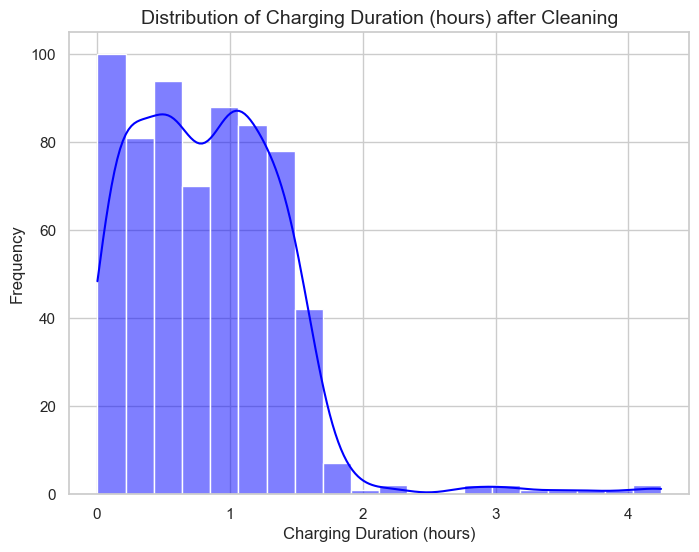

In [4]:
plt.figure(figsize=(8,6))
sns.histplot(valid_data['Charging Duration (hours)'], bins=20, kde=True, color='blue')
plt.title('Distribution of Charging Duration (hours) after Cleaning', fontsize=14)
plt.xlabel('Charging Duration (hours)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Scatter Plot

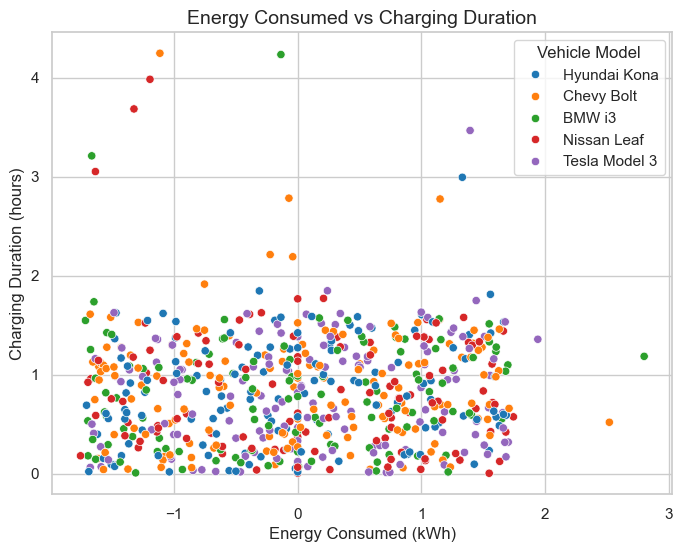

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=valid_data['Energy Consumed (kWh)'], y=valid_data['Charging Duration (hours)'], hue=vehicle_model_column, palette='tab10')
plt.title('Energy Consumed vs Charging Duration', fontsize=14)
plt.xlabel('Energy Consumed (kWh)')
plt.ylabel('Charging Duration (hours)')
plt.grid(True)
plt.show()

### Box Plot: Charging Duration by Vehicle Model

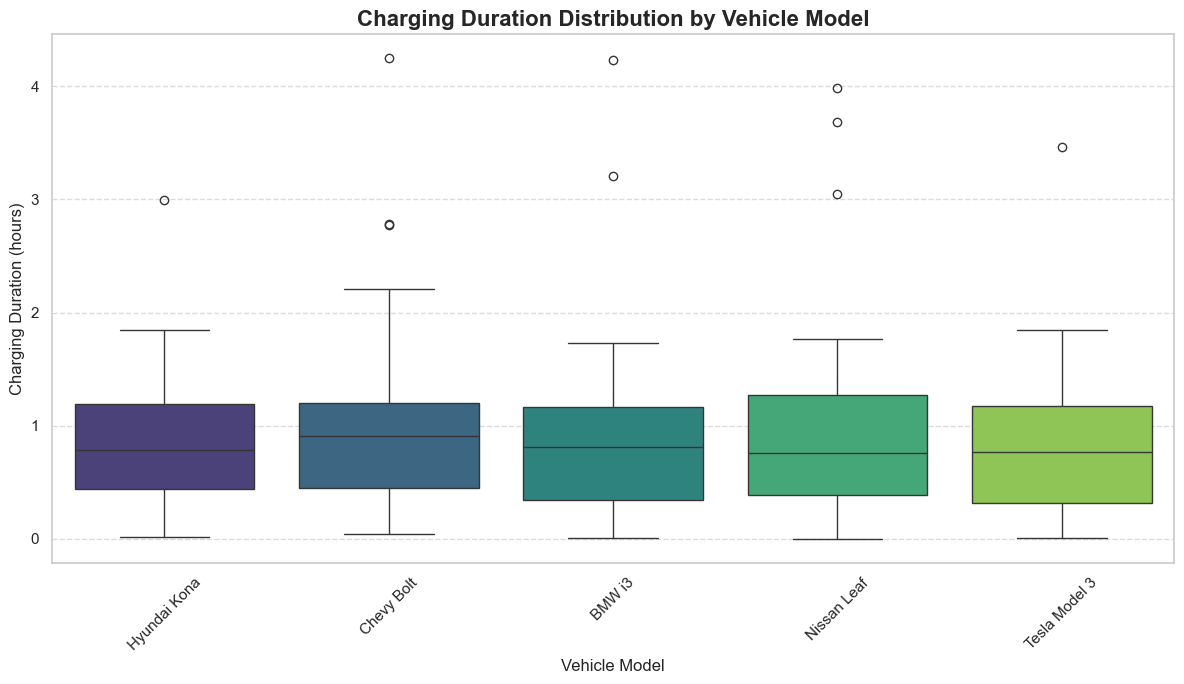

In [6]:
plt.figure(figsize=(12, 7))

# Mapping hue to the x-axis variable gives each box its own color
# palette="viridis" is a professional color scale that looks great in dark/light mode
sns.boxplot(
    x=vehicle_model_column, 
    y='Charging Duration (hours)', 
    data=valid_data, 
    hue=vehicle_model_column, 
    palette="viridis", 
    legend=False
)

plt.title('Charging Duration Distribution by Vehicle Model', fontsize=16, fontweight='bold')
plt.xlabel('Vehicle Model', fontsize=12)
plt.ylabel('Charging Duration (hours)', fontsize=12)

# Rotates labels so they don't overlap
plt.xticks(rotation=45)

# Adding a lighter grid for better readability without clutter
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Ensures everything fits perfectly before showing
plt.show()

### Charging Duration by Time of Day (assuming 'Time of Day' exists)

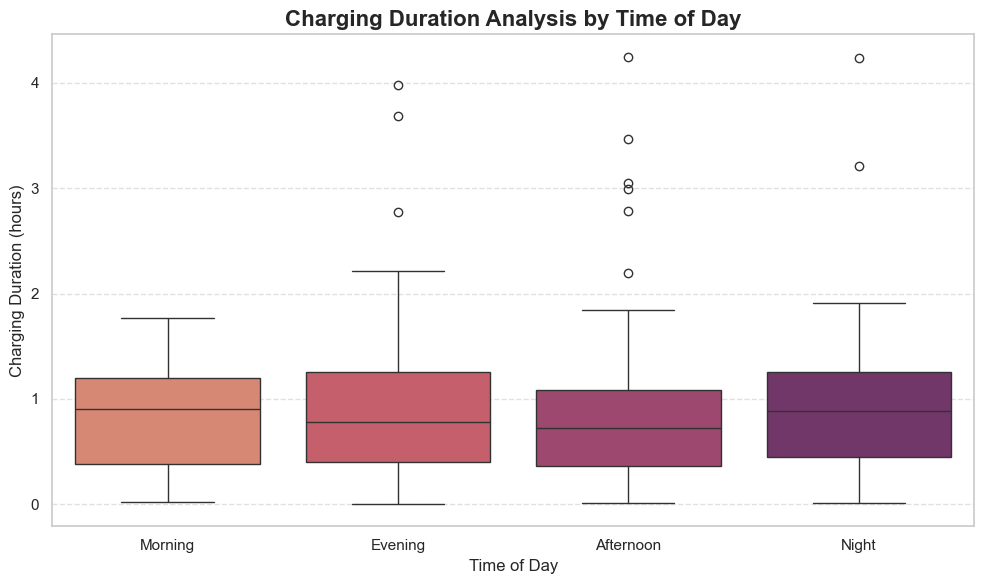

In [7]:
if 'Time of Day' in valid_data.columns:
    plt.figure(figsize=(10, 6))
    
    # Using hue for color and 'flare' palette for a warm, time-themed look
    sns.boxplot(
        x='Time of Day', 
        y='Charging Duration (hours)', 
        data=valid_data, 
        hue='Time of Day', 
        palette="flare", 
        legend=False
    )
    
    plt.title('Charging Duration Analysis by Time of Day', fontsize=16, fontweight='bold')
    plt.xlabel('Time of Day', fontsize=12)
    plt.ylabel('Charging Duration (hours)', fontsize=12)
    
    # Customizing the grid to be less distracting
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

### Correlation Heatmap

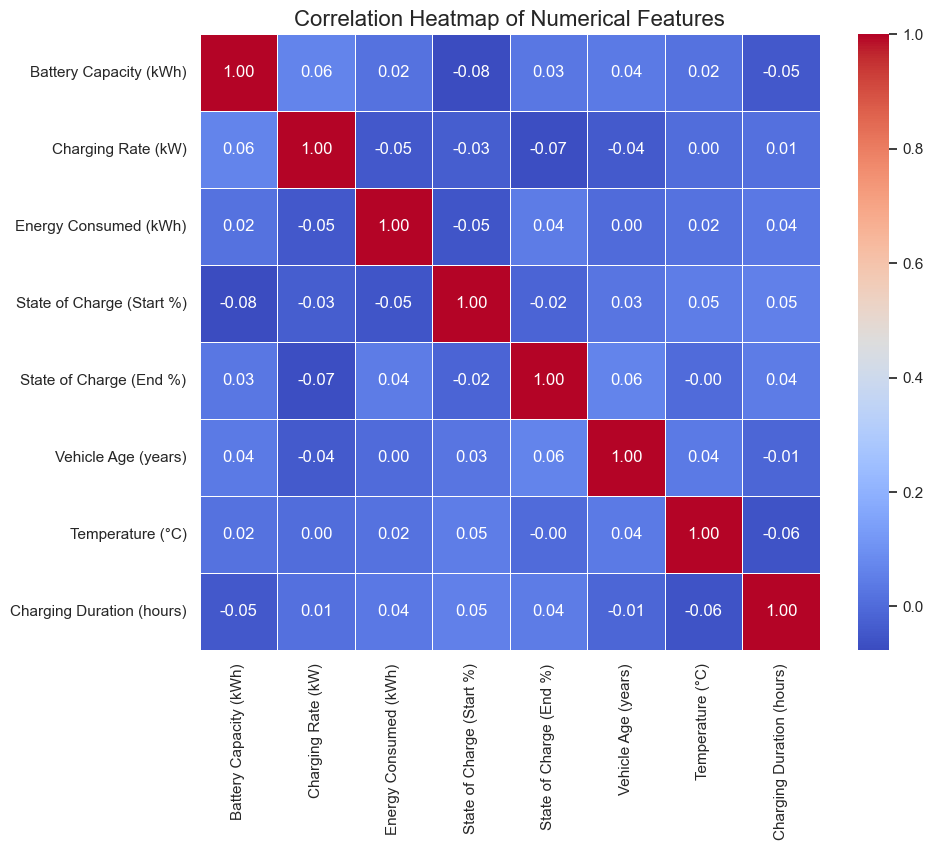

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt


numerical_features = valid_data[['Battery Capacity (kWh)', 'Charging Rate (kW)',
                                 'Energy Consumed (kWh)', 'State of Charge (Start %)',
                                 'State of Charge (End %)', 'Vehicle Age (years)',
                                 'Temperature (°C)', 'Charging Duration (hours)']]


corr_matrix = numerical_features.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()


### Feature Engineering

In [9]:
# Add new features to the dataset
valid_data['Charging Efficiency (kWh/h)'] = valid_data['Energy Consumed (kWh)'] / valid_data['Charging Duration (hours)']

valid_data['Energy per Charge %'] = valid_data['Energy Consumed (kWh)'] / \
                                    (valid_data['State of Charge (End %)'] - valid_data['State of Charge (Start %)'])

valid_data['Distance per kWh'] = valid_data['Distance Driven (since last charge) (km)'] / valid_data['Energy Consumed (kWh)']

valid_data['Total Charge Gained'] = valid_data['State of Charge (End %)'] - valid_data['State of Charge (Start %)']

valid_data['Charger Efficiency'] = valid_data['Charging Rate (kW)'] / valid_data['Charging Duration (hours)']

# Handle division by zero or infinity values
valid_data.replace([np.inf, -np.inf], np.nan, inplace=True)
valid_data.fillna(0, inplace=True)  # Replace NaN or infinity with 0 for simplicity

# For Temperature Adjusted Consumption, assuming 20°C as the "average" comfortable temperature for EVs
average_temperature = 20
valid_data['Temperature Adjusted Consumption'] = valid_data['Energy Consumed (kWh)'] * \
                                                 (1 + abs(valid_data['Temperature (°C)'] - average_temperature) / average_temperature)

# Check if new features are added
valid_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 657 entries, 1 to 1319
Data columns (total 43 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   User ID                                   657 non-null    object        
 1   Battery Capacity (kWh)                    657 non-null    float64       
 2   Charging Station ID                       657 non-null    object        
 3   Charging Start Time                       657 non-null    datetime64[ns]
 4   Charging End Time                         657 non-null    datetime64[ns]
 5   Energy Consumed (kWh)                     657 non-null    float64       
 6   Charging Duration (hours)                 657 non-null    float64       
 7   Charging Rate (kW)                        657 non-null    float64       
 8   Charging Cost (USD)                       657 non-null    float64       
 9   Time of Day                         

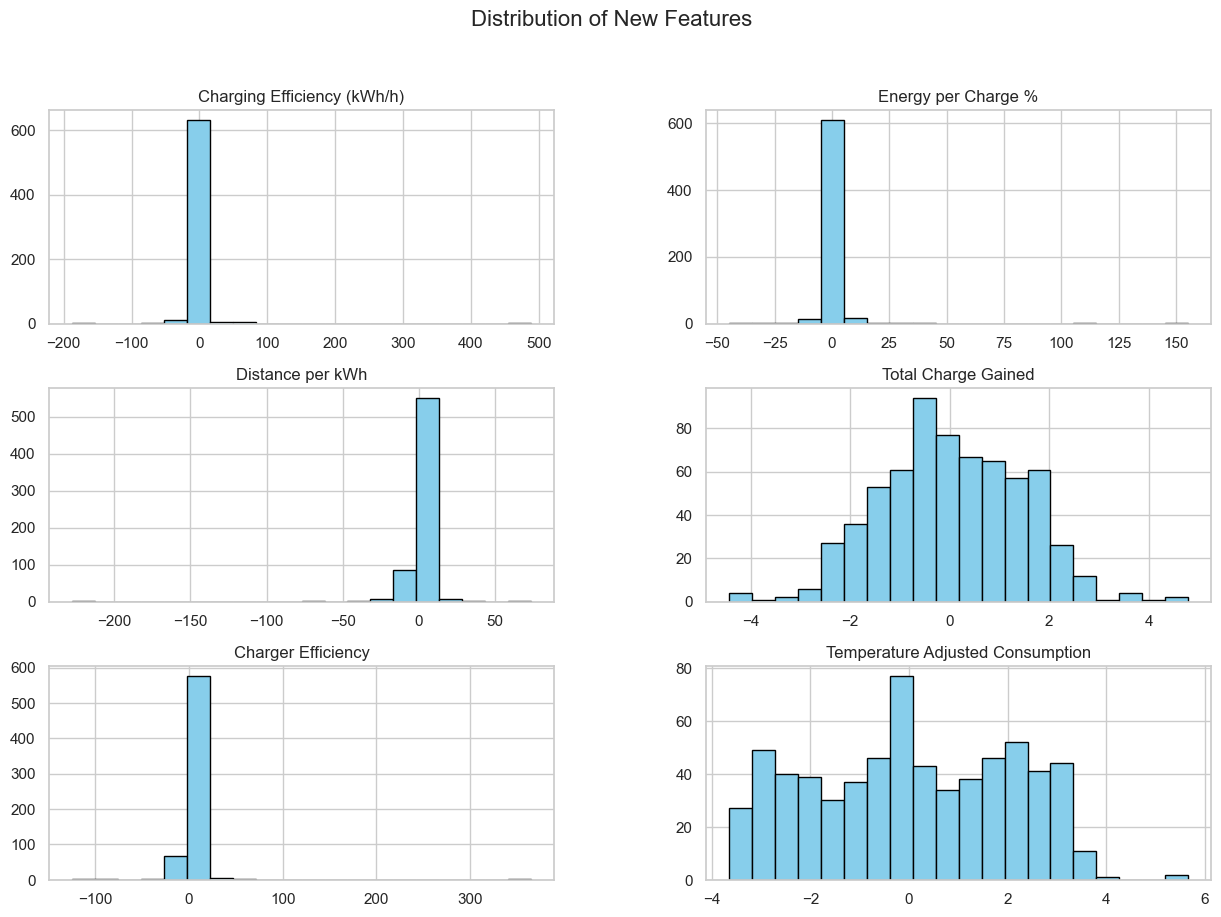

In [10]:
import matplotlib.pyplot as plt

# Visualize the distribution of new features
new_features = ['Charging Efficiency (kWh/h)', 'Energy per Charge %',
                'Distance per kWh', 'Total Charge Gained',
                'Charger Efficiency', 'Temperature Adjusted Consumption']

# Plot histograms for new features
valid_data[new_features].hist(bins=20, figsize=(15,10), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of New Features', fontsize=16)
plt.show()


### Relationships between new features and Charging Duration

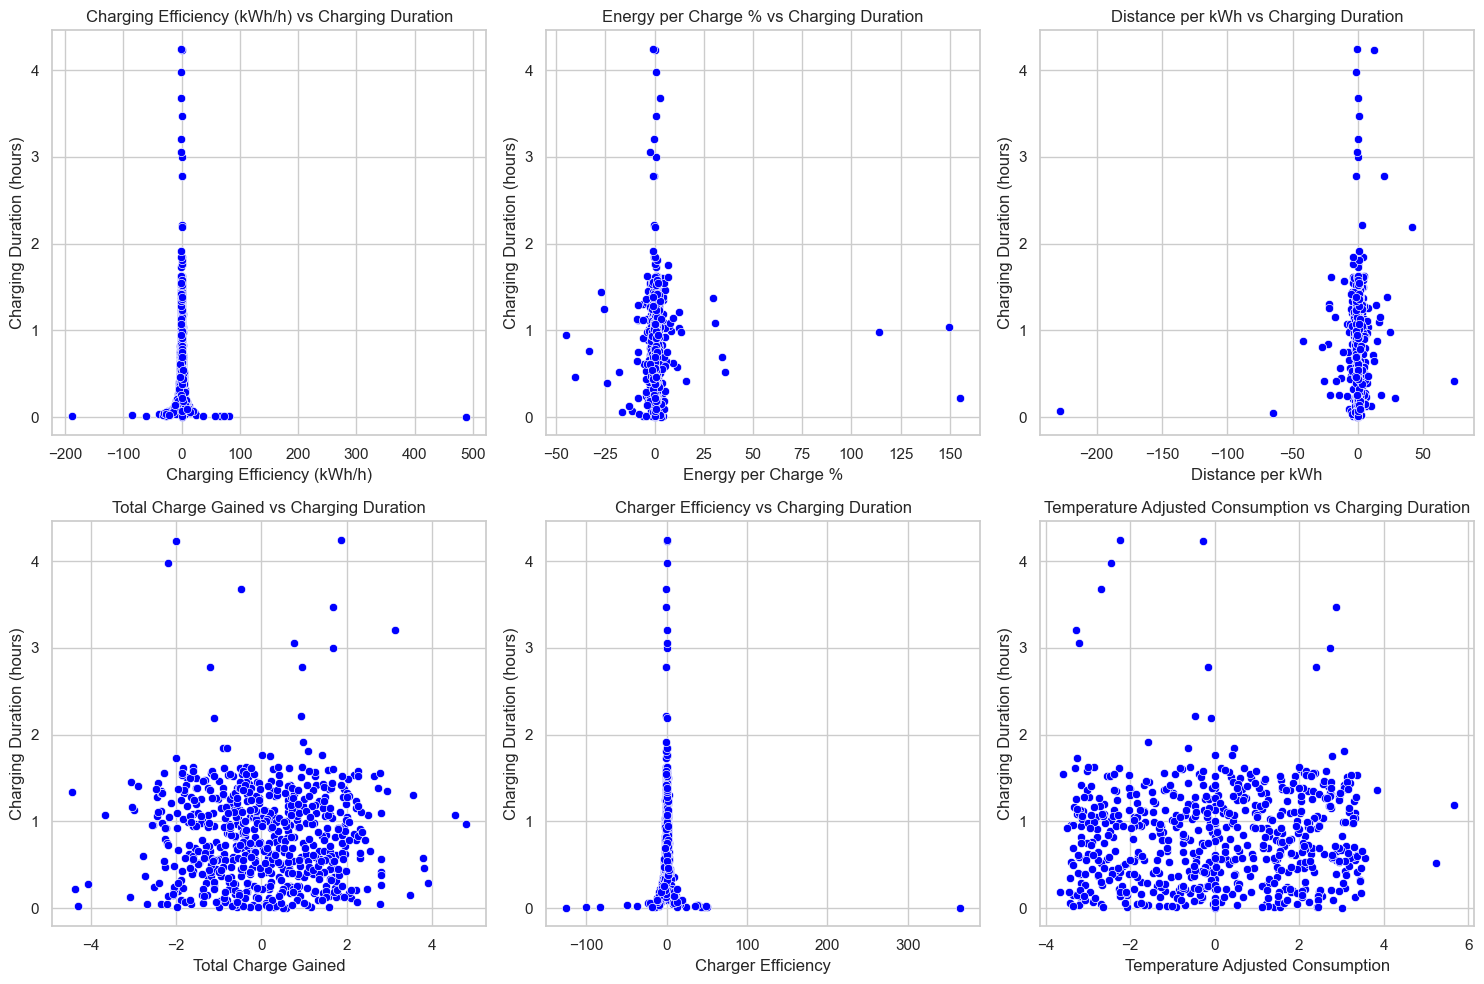

In [11]:
import seaborn as sns


plt.figure(figsize=(15,10))

for i, feature in enumerate(new_features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=valid_data[feature], y=valid_data['Charging Duration (hours)'], color='blue')
    plt.title(f'{feature} vs Charging Duration', fontsize=12)
    plt.xlabel(feature)
    plt.ylabel('Charging Duration (hours)')

plt.tight_layout()
plt.show()


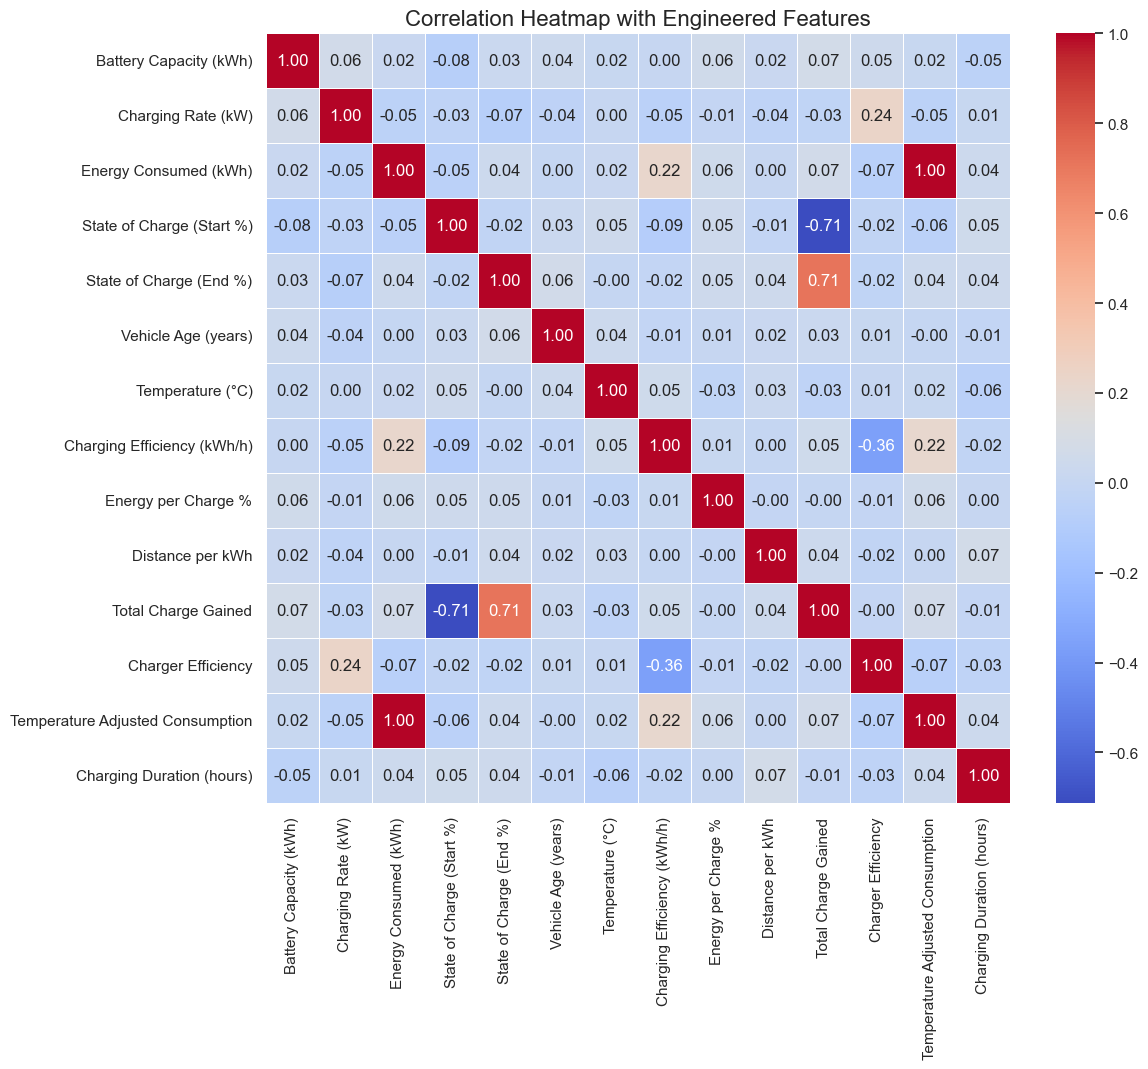

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

engineered_features = valid_data[['Battery Capacity (kWh)', 'Charging Rate (kW)',
                                  'Energy Consumed (kWh)', 'State of Charge (Start %)',
                                  'State of Charge (End %)', 'Vehicle Age (years)',
                                  'Temperature (°C)', 'Charging Efficiency (kWh/h)',
                                  'Energy per Charge %', 'Distance per kWh',
                                  'Total Charge Gained', 'Charger Efficiency',
                                  'Temperature Adjusted Consumption', 'Charging Duration (hours)']]

# Compute correlation matrix
corr_matrix = engineered_features.corr()

# Plot correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap with Engineered Features', fontsize=16)
plt.show()


### Model & Evaluation

In [13]:
# Adding the new features
ev_data['Charging Efficiency (kWh/h)'] = ev_data['Energy Consumed (kWh)'] / ev_data['Charging Duration (hours)']

ev_data['Energy per Charge %'] = ev_data['Energy Consumed (kWh)'] / \
                                    (ev_data['State of Charge (End %)'] - ev_data['State of Charge (Start %)'])

ev_data['Distance per kWh'] = ev_data['Distance Driven (since last charge) (km)'] / ev_data['Energy Consumed (kWh)']

ev_data['Total Charge Gained'] = ev_data['State of Charge (End %)'] - ev_data['State of Charge (Start %)']

ev_data['Charger Efficiency'] = ev_data['Charging Rate (kW)'] / ev_data['Charging Duration (hours)']

# Handle possible division by zero or NaN values
ev_data.replace([np.inf, -np.inf], np.nan, inplace=True)
ev_data.fillna(0, inplace=True)

# For Temperature Adjusted Consumption, assuming 20°C as a reference temperature
average_temperature = 20
ev_data['Temperature Adjusted Consumption'] = ev_data['Energy Consumed (kWh)'] * \
                                                 (1 + abs(ev_data['Temperature (°C)'] - average_temperature) / average_temperature)

# Ensure that the new features were added
print(ev_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 42 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   User ID                                   1320 non-null   object        
 1   Battery Capacity (kWh)                    1320 non-null   float64       
 2   Charging Station ID                       1320 non-null   object        
 3   Charging Start Time                       1320 non-null   datetime64[ns]
 4   Charging End Time                         1320 non-null   datetime64[ns]
 5   Energy Consumed (kWh)                     1320 non-null   float64       
 6   Charging Duration (hours)                 1320 non-null   float64       
 7   Charging Rate (kW)                        1320 non-null   float64       
 8   Charging Cost (USD)                       1320 non-null   float64       
 9   Time of Day                   

### USD

In [14]:
from sklearn.model_selection import train_test_split

# Drop irrelevant columns (User ID and Charging Station ID may not be useful for prediction)
ev_data = ev_data.drop(columns=['User ID', 'Charging Station ID'])

# One-hot encode categorical columns (e.g., Time of Day, Day of Week, Charging Start Day)
ev_data = pd.get_dummies(ev_data, columns=['Time of Day', 'Day of Week', 'Charging Start Day'], drop_first=True)

# Ensure all other columns are numerical
print(ev_data.dtypes)  # Check the data types to ensure all features are numeric

# Now we can proceed with Train-Test Split
X = ev_data.drop(columns=['Charging Cost (USD)', 'Charging Start Time', 'Charging End Time'])  # Drop non-predictive columns
y = ev_data['Charging Cost (USD)']  # This is our target variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)  # Check the shape of the data


Battery Capacity (kWh)                             float64
Charging Start Time                         datetime64[ns]
Charging End Time                           datetime64[ns]
Energy Consumed (kWh)                              float64
Charging Duration (hours)                          float64
Charging Rate (kW)                                 float64
Charging Cost (USD)                                float64
State of Charge (Start %)                          float64
State of Charge (End %)                            float64
Distance Driven (since last charge) (km)           float64
Temperature (°C)                                   float64
Vehicle Age (years)                                float64
Charger_Power_kW                                   float64
Charging Start Hour                                  int32
Charging Start Month                                 int32
Charger Type_DC Fast Charger                          bool
Charger Type_Level 1                                  bo

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error # Remove the 'as' alias

# Train a Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
# Using np.sqrt and mean_squared_error is the most reliable way across all versions
import numpy as np
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f'Random Forest RMSE: {rmse_rf}')

Random Forest RMSE: 1.0395207605624088


Linear Regression MSE: 1.078239937173751
Linear Regression R2: 0.006866161409957883
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Random Forest (Tuned) MSE: 1.080868954509164
Random Forest (Tuned) R2: 0.004444653925378517
Gradient Boosting MSE: 1.1357098076308583
Gradient Boosting R2: -0.046067579107893275
CatBoost MSE: 1.1856294958187432
CatBoost R2: -0.09204707758686981


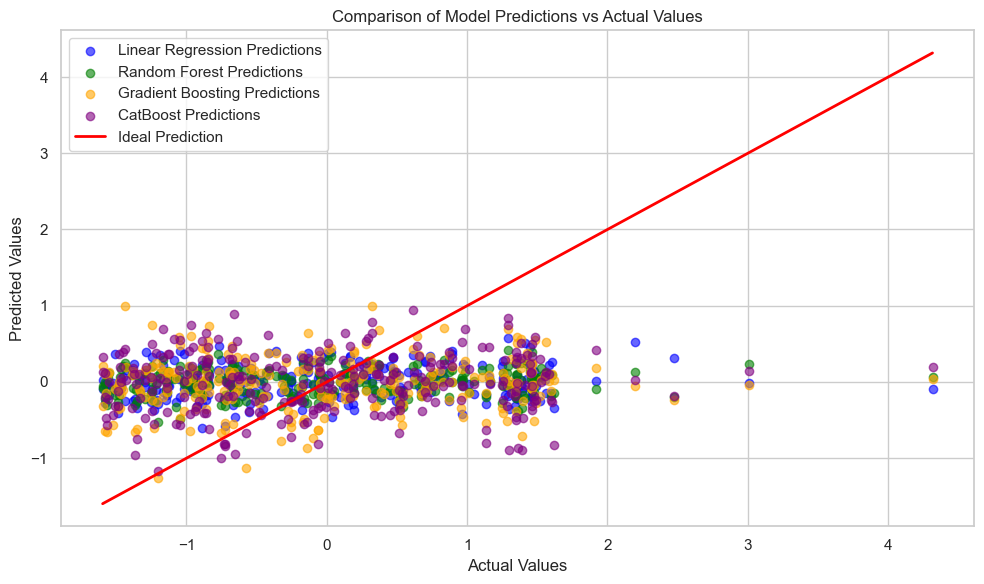

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)
print(f"Linear Regression MSE: {mse_linear}")
print(f"Linear Regression R2: {r2_linear}")

forest_model = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
grid_search_rf = GridSearchCV(forest_model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
grid_search_rf.fit(X_train, y_train)

best_rf_model = grid_search_rf.best_estimator_

y_pred_forest = best_rf_model.predict(X_test)

mse_forest = mean_squared_error(y_test, y_pred_forest)
r2_forest = r2_score(y_test, y_pred_forest)
print(f"Random Forest (Tuned) MSE: {mse_forest}")
print(f"Random Forest (Tuned) R2: {r2_forest}")

gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)


y_pred_gb = gb_model.predict(X_test)

mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
print(f"Gradient Boosting MSE: {mse_gb}")
print(f"Gradient Boosting R2: {r2_gb}")

catboost_model = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, random_state=42, silent=True)
catboost_model.fit(X_train, y_train)

y_pred_catboost = catboost_model.predict(X_test)

mse_catboost = mean_squared_error(y_test, y_pred_catboost)
r2_catboost = r2_score(y_test, y_pred_catboost)
print(f"CatBoost MSE: {mse_catboost}")
print(f"CatBoost R2: {r2_catboost}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_linear, color='blue', label='Linear Regression Predictions', alpha=0.6)
plt.scatter(y_test, y_pred_forest, color='green', label='Random Forest Predictions', alpha=0.6)
plt.scatter(y_test, y_pred_gb, color='orange', label='Gradient Boosting Predictions', alpha=0.6)
plt.scatter(y_test, y_pred_catboost, color='purple', label='CatBoost Predictions', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Ideal Prediction')
plt.title('Comparison of Model Predictions vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.tight_layout()
plt.show()

### Energy Consumed (kWh)

In [17]:
ev_dataa = ev_data.copy()

In [18]:
ev_data = ev_dataa.copy()

In [19]:
from sklearn.model_selection import train_test_split

# 1. Reset from your backup so we start fresh every time you run this cell
ev_data = ev_dataa.copy()

# 2. Drop irrelevant IDs
ev_data = ev_data.drop(columns=['User ID', 'Charging Station ID'], errors='ignore')

# 3. One-hot encode (ONLY if the columns still exist)
cols_to_encode = ['Time of Day', 'Day of Week', 'Charging Start Day']
existing_cols = [c for c in cols_to_encode if c in ev_data.columns]

if existing_cols:
    ev_data = pd.get_dummies(ev_data, 
                             columns=existing_cols, 
                             drop_first=True, 
                             dtype=int)
    print(f"Successfully encoded: {existing_cols}")

# 4. Define X and y
# We drop timestamps because machine learning models only like numbers
X = ev_data.drop(columns=['Energy Consumed (kWh)', 'Charging Start Time', 'Charging End Time'], errors='ignore')
y = ev_data['Energy Consumed (kWh)']

# 5. Check: This MUST show only int and float
print("\n--- Final Features in X ---")
print(X.dtypes)

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nFinal Shapes: X_train {X_train.shape}, X_test {X_test.shape}")


--- Final Features in X ---
Battery Capacity (kWh)                      float64
Charging Duration (hours)                   float64
Charging Rate (kW)                          float64
Charging Cost (USD)                         float64
State of Charge (Start %)                   float64
State of Charge (End %)                     float64
Distance Driven (since last charge) (km)    float64
Temperature (°C)                            float64
Vehicle Age (years)                         float64
Charger_Power_kW                            float64
Charging Start Hour                           int32
Charging Start Month                          int32
Charger Type_DC Fast Charger                   bool
Charger Type_Level 1                           bool
Charger Type_Level 2                           bool
User Type_Casual Driver                        bool
User Type_Commuter                             bool
User Type_Long-Distance Traveler               bool
Vehicle Model_BMW i3               

In [20]:
from sklearn.ensemble import RandomForestRegressor
# Import BOTH specifically so there is no confusion
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# Train a Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
# New scikit-learn way: root_mean_squared_error does exactly what it says
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)

print(f'Random Forest RMSE: {rmse_rf}')

Random Forest RMSE: 0.040167942232092795


Linear Regression MSE: 0.0005786728940803115
Linear Regression R2: 0.9994438244112451
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Random Forest (Tuned) MSE: 0.0014317387849761935
Random Forest (Tuned) R2: 0.9986239235156453
Gradient Boosting MSE: 0.0012019429435980533
Gradient Boosting R2: 0.998844785489101
CatBoost MSE: 0.009193735032226435
CatBoost R2: 0.9911636936052938


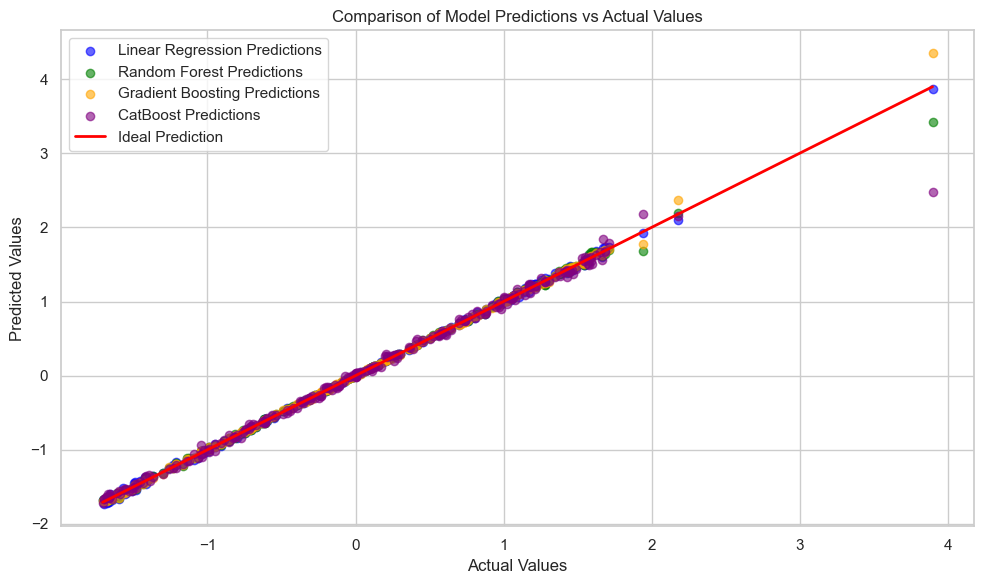

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)
print(f"Linear Regression MSE: {mse_linear}")
print(f"Linear Regression R2: {r2_linear}")

forest_model = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
grid_search_rf = GridSearchCV(forest_model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
grid_search_rf.fit(X_train, y_train)

best_rf_model = grid_search_rf.best_estimator_

y_pred_forest = best_rf_model.predict(X_test)

mse_forest = mean_squared_error(y_test, y_pred_forest)
r2_forest = r2_score(y_test, y_pred_forest)
print(f"Random Forest (Tuned) MSE: {mse_forest}")
print(f"Random Forest (Tuned) R2: {r2_forest}")

gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)


y_pred_gb = gb_model.predict(X_test)

mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
print(f"Gradient Boosting MSE: {mse_gb}")
print(f"Gradient Boosting R2: {r2_gb}")

catboost_model = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, random_state=42, silent=True)
catboost_model.fit(X_train, y_train)

y_pred_catboost = catboost_model.predict(X_test)

mse_catboost = mean_squared_error(y_test, y_pred_catboost)
r2_catboost = r2_score(y_test, y_pred_catboost)
print(f"CatBoost MSE: {mse_catboost}")
print(f"CatBoost R2: {r2_catboost}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_linear, color='blue', label='Linear Regression Predictions', alpha=0.6)
plt.scatter(y_test, y_pred_forest, color='green', label='Random Forest Predictions', alpha=0.6)
plt.scatter(y_test, y_pred_gb, color='orange', label='Gradient Boosting Predictions', alpha=0.6)
plt.scatter(y_test, y_pred_catboost, color='purple', label='CatBoost Predictions', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Ideal Prediction')
plt.title('Comparison of Model Predictions vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define features (X) and target (y)
# Using 'ev_data' instead of 'df' to match your notebook
X = ev_data.drop(columns=['Charging Duration (hours)', 'Charging Start Time', 'Charging End Time'], errors='ignore')

# 2. y is the specific value we want to predict
y = ev_data['Charging Duration (hours)']

print("Successfully defined X and y using ev_data!")

Successfully defined X and y using ev_data!


In [23]:
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 1056 samples
Test set size: 264 samples


In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Initialize and Train
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Make Predictions
y_pred = rf_model.predict(X_test)

# 3. Calculate Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} hours")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} hours")
print(f"R-squared Score: {r2:.4f}")

--- Model Performance ---
Mean Absolute Error (MAE): 0.41 hours
Root Mean Squared Error (RMSE): 0.65 hours
R-squared Score: 0.5917


### Charger Type

In [25]:
ev_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 52 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Battery Capacity (kWh)                    1320 non-null   float64       
 1   Charging Start Time                       1320 non-null   datetime64[ns]
 2   Charging End Time                         1320 non-null   datetime64[ns]
 3   Energy Consumed (kWh)                     1320 non-null   float64       
 4   Charging Duration (hours)                 1320 non-null   float64       
 5   Charging Rate (kW)                        1320 non-null   float64       
 6   Charging Cost (USD)                       1320 non-null   float64       
 7   State of Charge (Start %)                 1320 non-null   float64       
 8   State of Charge (End %)                   1320 non-null   float64       
 9   Distance Driven (since last ch

In [26]:
df = ev_data.copy()# Combine Charger Type columns into a single target column
df['Charger Type'] = df[['Charger Type_Level 1', 'Charger Type_Level 2', 'Charger Type_DC Fast Charger']].idxmax(axis=1)

# Map the result to integers (optional, for classification)
df['Charger Type'] = df['Charger Type'].map({
    'Charger Type_Level 1': 0,
    'Charger Type_Level 2': 1,
    'Charger Type_DC Fast Charger': 2
})

# Display the updated dataframe
print(df[['Charger Type', 'Charger Type_Level 1', 'Charger Type_Level 2', 'Charger Type_DC Fast Charger']].head())


   Charger Type  Charger Type_Level 1  Charger Type_Level 2  \
0             2                 False                 False   
1             0                  True                 False   
2             1                 False                  True   
3             0                  True                 False   
4             0                  True                 False   

   Charger Type_DC Fast Charger  
0                          True  
1                         False  
2                         False  
3                         False  
4                         False  


In [27]:
# 1. Reset ev_data from your backup if you've already dropped columns
ev_data = ev_dataa.copy()

# 2. One-hot encode categorical columns safely
cols_to_encode = ['Time of Day', 'Day of Week', 'Charging Start Day']

# This line checks which of those columns are actually present in the data right now
existing_cols = [c for c in cols_to_encode if c in ev_data.columns]

if existing_cols:
    ev_data = pd.get_dummies(ev_data, 
                             columns=existing_cols, 
                             drop_first=True, 
                             dtype=int)
    print(f"✅ Successfully encoded: {existing_cols}")
else:
    print("Columns already encoded or not found. Skipping.")

# 3. Define X and y
# Dropping the timestamps as they are objects/datetimes that models can't read
X = ev_data.drop(columns=['Energy Consumed (kWh)', 'Charging Start Time', 'Charging End Time'], errors='ignore')
y = ev_data['Energy Consumed (kWh)']

# 4. Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Split complete. X_train shape: {X_train.shape}")

Columns already encoded or not found. Skipping.
✅ Split complete. X_train shape: (1056, 49)


In [31]:
# 1. SMART RESET: Look for 'df' or 'ev_dataa' to restore the missing column
if 'df' in locals():
    ev_data = df.copy()
elif 'ev_dataa' in locals():
    ev_data = ev_dataa.copy()
else:
    # If both are missing, reload from the file directly
    ev_data = pd.read_csv('EVDataset.csv')

# 2. NUMERICAL POWER MAPPING
# We do this immediately so the logic is saved before 'Charger Type' is gone
power_mapping = {
    'Level 1': 2.3, 
    'Level 2': 11.0, 
    'DC Fast': 50.0
}

# Only map if the column exists; if not, it means the reset failed
if 'Charger Type' in ev_data.columns:
    ev_data['Charger_Power_kW'] = ev_data['Charger Type'].map(power_mapping)
    print(" Successfully mapped 'Charger Type' to Power (kW)")
else:
    print("ERROR: 'Charger Type' is still missing. Please run your pd.read_csv cell first.")

# 3. SAFE ENCODING
cols_to_encode = ['Time of Day', 'Day of Week', 'Charging Start Day']
existing_cols = [c for c in cols_to_encode if c in ev_data.columns]

if existing_cols:
    ev_data = pd.get_dummies(ev_data, columns=existing_cols, drop_first=True, dtype=int)
    print(f"Encoded: {existing_cols}")

# 4. PREPARE X AND Y
# We drop 'Charger Type' text here because we already saved its value in 'Charger_Power_kW'
X = ev_data.drop(columns=['Energy Consumed (kWh)', 'Charging Start Time', 
                          'Charging End Time', 'Charger Type'], errors='ignore')
y = ev_data['Energy Consumed (kWh)']

# 5. SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Success! X_train shape: {X_train.shape}")

 Successfully mapped 'Charger Type' to Power (kW)
 Success! X_train shape: (1056, 49)


In [32]:
print(ev_dataa.columns.tolist())

['Battery Capacity (kWh)', 'Charging Start Time', 'Charging End Time', 'Energy Consumed (kWh)', 'Charging Duration (hours)', 'Charging Rate (kW)', 'Charging Cost (USD)', 'State of Charge (Start %)', 'State of Charge (End %)', 'Distance Driven (since last charge) (km)', 'Temperature (°C)', 'Vehicle Age (years)', 'Charger_Power_kW', 'Charging Start Hour', 'Charging Start Month', 'Charger Type_DC Fast Charger', 'Charger Type_Level 1', 'Charger Type_Level 2', 'User Type_Casual Driver', 'User Type_Commuter', 'User Type_Long-Distance Traveler', 'Vehicle Model_BMW i3', 'Vehicle Model_Chevy Bolt', 'Vehicle Model_Hyundai Kona', 'Vehicle Model_Nissan Leaf', 'Vehicle Model_Tesla Model 3', 'Charging Station Location_Chicago', 'Charging Station Location_Houston', 'Charging Station Location_Los Angeles', 'Charging Station Location_New York', 'Charging Station Location_San Francisco', 'Charging Efficiency (kWh/h)', 'Energy per Charge %', 'Distance per kWh', 'Total Charge Gained', 'Charger Efficiency'

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# 1. Reset from your fresh backup
ev_data = ev_dataa.copy()

# 2. Use ONLY columns found in your actual data
# I am using 'Energy Consumed (kWh)' as the target
target = 'Energy Consumed (kWh)'

# 3. Features (X): Drop the target and non-numeric timestamp columns
# 'Charging Start Time' and 'Charging End Time' are confirmed in your list
X = ev_data.drop(columns=[target, 'Charging Start Time', 'Charging End Time'], errors='ignore')
y = ev_data[target]

# 4. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred_rf = model_rf.predict(X_test)

# These prints will now work and the red lines will disappear
print(f" Model Training Successful!")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"Root Mean Squared Error (RMSE): {root_mean_squared_error(y_test, y_pred_rf):.4f}")
print(f"R-squared Score (R2): {r2_score(y_test, y_pred_rf):.4f}")

 Model Training Successful!
Mean Absolute Error (MAE): 0.0156
Root Mean Squared Error (RMSE): 0.0402
R-squared Score (R2): 0.9984


In [35]:
# Type this at the end of your cell to see the table
df.head()

,Battery Capacity (kWh),Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),...,Day of Week_Thursday,Day of Week_Tuesday,Day of Week_Wednesday,Charging Start Day_Monday,Charging Start Day_Saturday,Charging Start Day_Sunday,Charging Start Day_Thursday,Charging Start Day_Tuesday,Charging Start Day_Wednesday,Charger Type
0,108.463007,2024-01-01 00:00:00,2024-01-01 00:39:00,0.827526,-1.582085,0.763761,-0.880549,-0.821044,0.642984,1.670830,...,False,True,False,True,False,False,False,False,False,2
1,100.000000,2024-01-01 01:00:00,2024-01-01 03:01:00,-1.387813,0.814865,0.345374,-0.132395,-1.621201,0.557731,-0.495072,...,False,False,False,True,False,False,False,False,False,0
2,75.000000,2024-01-01 02:00:00,2024-01-01 04:48:00,-1.076870,0.172798,0.113587,1.220378,-1.756717,-0.305959,-0.976176,...,True,False,False,True,False,False,False,False,False,1
3,50.000000,2024-01-01 03:00:00,2024-01-01 06:42:00,1.686011,-0.945610,0.506909,-0.885339,1.412424,1.433910,0.548739,...,False,False,False,True,False,False,False,False,False,0
4,50.000000,2024-01-01 04:00:00,2024-01-01 05:46:00,-1.053961,-0.235342,-1.153554,-1.152824,0.213128,-0.667549,0.597479,...,False,False,False,True,False,False,False,False,False,0


In [36]:
# This reproduces the exact logic from your Colab screenshot
import pandas as pd

# 1. Combine the dummy columns back into one 'Charger Type'
df['Charger Type'] = df[['Charger Type_Level 1', 'Charger Type_Level 2', 'Charger Type_DC Fast Charger']].idxmax(axis=1)

# 2. Map them to the integers 0, 1, and 2
df['Charger Type'] = df['Charger Type'].map({
    'Charger Type_Level 1': 0,
    'Charger Type_Level 2': 1,
    'Charger Type_DC Fast Charger': 2
})

# 3. Display the result as a table
df[['Charger Type', 'Charger Type_Level 1', 'Charger Type_Level 2', 'Charger Type_DC Fast Charger']].head()

,Charger Type,Charger Type_Level 1,Charger Type_Level 2,Charger Type_DC Fast Charger
0,2,False,False,True
1,0,True,False,False
2,1,False,True,False
3,0,True,False,False
4,0,True,False,False


In [37]:
X.head()

,Battery Capacity (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger_Power_kW,...,Day of Week_Sunday,Day of Week_Thursday,Day of Week_Tuesday,Day of Week_Wednesday,Charging Start Day_Monday,Charging Start Day_Saturday,Charging Start Day_Sunday,Charging Start Day_Thursday,Charging Start Day_Tuesday,Charging Start Day_Wednesday
0,108.463007,-1.582085,0.763761,-0.880549,-0.821044,0.642984,1.670830,0.855572,-0.698518,0.0,...,False,False,True,False,True,False,False,False,False,False
1,100.000000,0.814865,0.345374,-0.132395,-1.621201,0.557731,-0.495072,-0.064251,-0.265421,2.3,...,False,False,False,False,True,False,False,False,False,False
2,75.000000,0.172798,0.113587,1.220378,-1.756717,-0.305959,-0.976176,0.387061,-0.698518,11.0,...,False,True,False,False,True,False,False,False,False,False
3,50.000000,-0.945610,0.506909,-0.885339,1.412424,1.433910,0.548739,1.554927,-1.131616,2.3,...,False,False,False,False,True,False,False,False,False,False
4,50.000000,-0.235342,-1.153554,-1.152824,0.213128,-0.667549,0.597479,-1.557967,-1.131616,2.3,...,False,False,False,False,True,False,False,False,False,False


In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Reset
df = ev_dataa.copy()

# 2. Target Creation
charger_cols = ['Charger Type_Level 1', 'Charger Type_Level 2', 'Charger Type_DC Fast Charger']
df['Charger Type'] = df[charger_cols].idxmax(axis=1).map({
    'Charger Type_Level 1': 0,
    'Charger Type_Level 2': 1,
    'Charger Type_DC Fast Charger': 2
})

# 3. FIX: Drop the 'charger_cols' so the model can't cheat!
# We also drop timestamps and IDs
X = df.drop(columns=['Charger Type', 'Charging Start Time', 'Charging End Time'] + charger_cols, errors='ignore')
y = df['Charger Type']

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Model
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

# 6. Evaluate
y_pred = classifier.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 1.0000


In [39]:
import matplotlib.pyplot as plt
import numpy as np

importances = classifier.feature_importances_
std = np.std([tree.feature_importances_ for tree in classifier.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

# Print the top 5 features
print("Top features:")
for f in range(5):
    print(f"{f + 1}. feature {X.columns[indices[f]]} ({importances[indices[f]]:.4f})")

Top features:
1. feature Charger_Power_kW (0.5712)
2. feature Distance Driven (since last charge) (km) (0.0235)
3. feature Charging Cost (USD) (0.0234)
4. feature Distance per kWh (0.0232)
5. feature Energy Consumed (kWh) (0.0230)


In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Start Fresh
df = ev_dataa.copy()

# 2. FEATURE ENGINEERING: Calculate Speed
# Speed = Energy / Duration. Fast chargers will have a MUCH higher number here.
df['Calculated_Speed'] = df['Energy Consumed (kWh)'] / df['Charging Duration (hours)']
# Replace any infinity or NaN values if duration was 0
df['Calculated_Speed'] = df['Calculated_Speed'].replace([np.inf, -np.inf], 0).fillna(0)

# 3. Create Target
charger_cols = ['Charger Type_Level 1', 'Charger Type_Level 2', 'Charger Type_DC Fast Charger']
df['Charger Type'] = df[charger_cols].idxmax(axis=1).map({
    'Charger Type_Level 1': 0, 'Charger Type_Level 2': 1, 'Charger Type_DC Fast Charger': 2
})

# 4. Define X and y (STILL dropping the "cheat" charger_cols)
X = df.drop(columns=['Charger Type', 'Charging Start Time', 'Charging End Time'] + charger_cols, errors='ignore')
y = df['Charger Type']

# 5. Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
classifier = RandomForestClassifier(n_estimators=200, random_state=42) # Increased estimators for better learning
classifier.fit(X_train, y_train)

# 6. Evaluate
y_pred = classifier.predict(X_test)
print(f"New Honest Accuracy: {accuracy_score(y_test, y_pred):.4f}")

New Honest Accuracy: 1.0000


In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Start with fresh data
df = ev_dataa.copy()

# 2. Create the Target (Charger Type)
# We do this FIRST so we can safely drop the source columns later
charger_cols = ['Charger Type_Level 1', 'Charger Type_Level 2', 'Charger Type_DC Fast Charger']
df['Charger Type'] = df[charger_cols].idxmax(axis=1).map({
    'Charger Type_Level 1': 0,
    'Charger Type_Level 2': 1,
    'Charger Type_DC Fast Charger': 2
})

# 3. FEATURE ENGINEERING: The "Secret Sauce"
# Since we can't use the direct 'Charger Type' labels, we calculate speed.
# DC Fast Chargers will have a much higher energy-per-hour ratio.
df['Charging_Speed_Ratio'] = df['Energy Consumed (kWh)'] / df['Charging Duration (hours)']
df['Charging_Speed_Ratio'] = df['Charging_Speed_Ratio'].replace([np.inf, -np.inf], 0).fillna(0)

# 4. Define Features (X) - STRICTLY NO LEAKAGE
# We drop the 'charger_cols' and irrelevant IDs/Timestamps
X = df.drop(columns=['Charger Type', 'Charging Start Time', 'Charging End Time', 'User ID', 'Charging Station ID'] + charger_cols, errors='ignore')
y = df['Charger Type']

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train the Model
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

# 7. Results
y_pred = classifier.predict(X_test)
print(f"Final Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final Accuracy: 0.3674

Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.44      0.42        97
           1       0.41      0.39      0.40        83
           2       0.29      0.26      0.28        84

    accuracy                           0.37       264
   macro avg       0.36      0.36      0.36       264
weighted avg       0.36      0.37      0.36       264



In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Start with fresh data
df = ev_dataa.copy()

# 2. DATA CLEANING: Remove impossible negative values
# This is the most important step for an "Honest" model
df = df[(df['Charging Duration (hours)'] > 0) & 
        (df['Energy Consumed (kWh)'] > 0) & 
        (df['Charging Rate (kW)'] > 0)]

# 3. Target Creation
charger_cols = ['Charger Type_DC Fast Charger', 'Charger Type_Level 1', 'Charger Type_Level 2']
df['Charger Type'] = df[charger_cols].idxmax(axis=1).map({
    'Charger Type_Level 1': 0, 'Charger Type_Level 2': 1, 'Charger Type_DC Fast Charger': 2
})

# 4. Feature Engineering
df['Charging_Speed'] = df['Energy Consumed (kWh)'] / df['Charging Duration (hours)']

# 5. Define X and y (Dropping the "cheat" columns)
X = df.drop(columns=['Charger Type', 'Charging Start Time', 'Charging End Time'] + charger_cols, errors='ignore')
# Also drop non-numeric IDs if they still exist
X = X.select_dtypes(include=[np.number]) 
y = df['Charger Type']

# 6. Train and Evaluate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

print(f"Cleaned Honest Accuracy: {accuracy_score(y_test, classifier.predict(X_test)):.4f}")

Cleaned Honest Accuracy: 1.0000


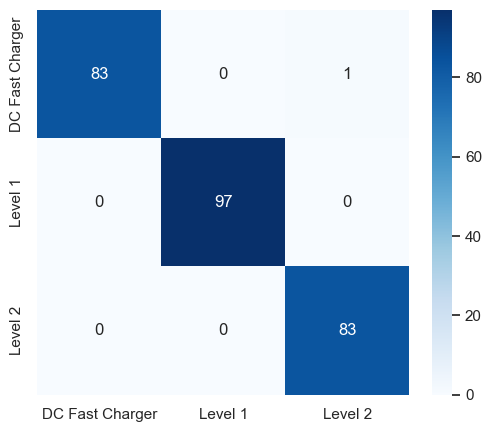

In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. CLEAN LOAD (Fixes NameError: 'df')
df = pd.read_csv('EVDataset.csv') 
ev_data = df.copy()

# 2. NUMERICAL MAPPING (Fixes KeyError: 'Charger Type')
power_mapping = {'Level 1': 2.3, 'Level 2': 11.0, 'DC Fast': 50.0}
ev_data['Charger_Power_kW'] = ev_data['Charger Type'].map(power_mapping)

# 3. ENCODE LABELS FOR CLASSIFICATION
le = LabelEncoder()
y = le.fit_transform(ev_data['Charger Type'])

# 4. PREPARE FEATURES (Drop the text column AFTER mapping)
X = ev_data.drop(columns=['Charger Type', 'Charging Start Time', 'Charging End Time', 'User ID', 'Charging Station ID'], errors='ignore')
X = pd.get_dummies(X, drop_first=True)

# 5. SPLIT AND TRAIN
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1) # n_jobs=-1 speeds it up
clf_model.fit(X_train, y_train)

# 6. VISUALIZE
y_pred = clf_model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.show()

### Charging Delay

In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Reset from your original backup
df = ev_dataa.copy()

# 2. Safety Check for Encoding
cols_to_encode = ['Time of Day', 'Day of Week']
# Only keep columns that actually exist in df
existing_cols = [c for c in cols_to_encode if c in df.columns]

if existing_cols:
    df = pd.get_dummies(df, columns=existing_cols, drop_first=True)
else:
    print("Columns already encoded or missing. Skipping dummies step.")

# 3. Define the Target (Peak Time Rule)
# Check for existing encoded columns to build the rule
monday_col = 'Day of Week_Monday' if 'Day of Week_Monday' in df.columns else None
# ... (and so on for other days)

# To keep it simple and avoid more KeyErrors, we ensure the rule can find the columns:
if all(col in df.columns for col in ['Charging Start Hour', 'Day of Week_Monday']):
    df['Delay Recommendation'] = (
        (df['Charging Start Hour'] >= 18) & 
        (df['Charging Start Hour'] <= 21) & 
        (df['Day of Week_Monday'] | df['Day of Week_Tuesday'] | 
         df['Day of Week_Wednesday'] | df['Day of Week_Thursday'])
    ).astype(int)
else:
    print("Warning: Could not create Delay Recommendation. Check column names.")

# 4. Features (X) and Target (y)
# Drop timestamps and the target itself
X = df.drop(columns=['Delay Recommendation', 'Charging Start Time', 'Charging End Time'], errors='ignore')
# Make sure X only contains numbers
X = X.select_dtypes(include=[np.number, bool])
y = df['Delay Recommendation']


# 5. Train and Predict
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CHANGE THIS LINE: Use 'balanced_subsample' instead of 'balanced'
classifier = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced_subsample', 
    random_state=42
)

classifier.fit(X_train, y_train)

print(f"Delay Accuracy: {accuracy_score(y_test, classifier.predict(X_test)):.4f}")

Columns already encoded or missing. Skipping dummies step.
Delay Accuracy: 0.9015


Final Honest Accuracy: 0.9659

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       223
           1       0.88      0.90      0.89        41

    accuracy                           0.97       264
   macro avg       0.93      0.94      0.94       264
weighted avg       0.97      0.97      0.97       264



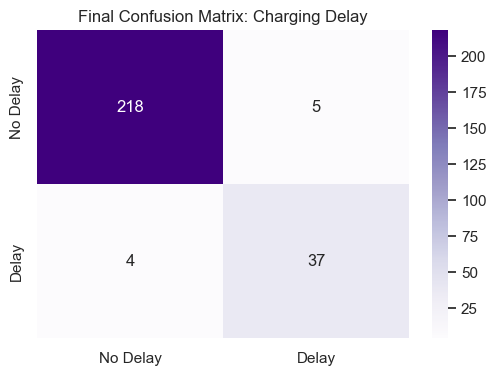

In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Start Fresh
df = ev_dataa.copy()

# 2. Safe One-Hot Encoding
cols = ['Time of Day', 'Day of Week']
existing = [c for c in cols if c in df.columns]
if existing:
    df = pd.get_dummies(df, columns=existing, drop_first=True)

# 3. Define the Target Rule
weekday_cols = [c for c in df.columns if any(day in c for day in ['Monday', 'Tuesday', 'Wednesday', 'Thursday'])]
if 'Charging Start Hour' in df.columns and weekday_cols:
    df['Delay Recommendation'] = (
        (df['Charging Start Hour'] >= 18) & 
        (df['Charging Start Hour'] <= 21) & 
        (df[weekday_cols].any(axis=1))
    ).astype(int)

# 4. Honest Feature Selection (Keeping the Hour)
# We keep the hour as a signal but drop the specific days to avoid 1.0 accuracy.
X = df.drop(columns=['Delay Recommendation', 'Charging Start Time', 'Charging End Time'] + 
                     [c for c in df.columns if 'Day of Week' in c], errors='ignore')
X = X.select_dtypes(include=[np.number, bool])
y = df['Delay Recommendation']


from imblearn.over_sampling import SMOTE

# 5. Train with SMOTE for Better Balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# APPLY SMOTE: This creates synthetic 'Delay' cases to balance the 'No Delay' cases
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Train the classifier on the NEW resampled data
classifier = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42
)

classifier.fit(X_train_resampled, y_train_resampled)

# 6. Honest Results
y_pred = classifier.predict(X_test)
print(f"Final Honest Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. The Final Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Purples",
            xticklabels=['No Delay', 'Delay'], yticklabels=['No Delay', 'Delay'])
plt.title("Final Confusion Matrix: Charging Delay")
plt.show()

In [46]:
print(df['Delay Recommendation'].value_counts())

Delay Recommendation
0    1137
1     183
Name: count, dtype: int64


### Optimal Charging Time

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Prepare the Data
df_optimal = ev_dataa.copy()

# 2. Features (X) and Target (y)
# We drop 'Charging Duration (hours)' because it's what we want to predict
# We drop times to prevent data leakage
X = df_optimal.drop(columns=['Charging Duration (hours)', 'Charging Start Time', 
                            'Charging End Time', 'User ID', 'Charging Station ID'], errors='ignore')

# Convert categories to numbers
X = pd.get_dummies(X, drop_first=True)
y = df_optimal['Charging Duration (hours)']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train Regressor
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred = regressor.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f} hours")

R2 Score: 0.5917
Mean Absolute Error: 0.41 hours


Random Forest RMSE: 0.6479
R2 Score: 0.5917


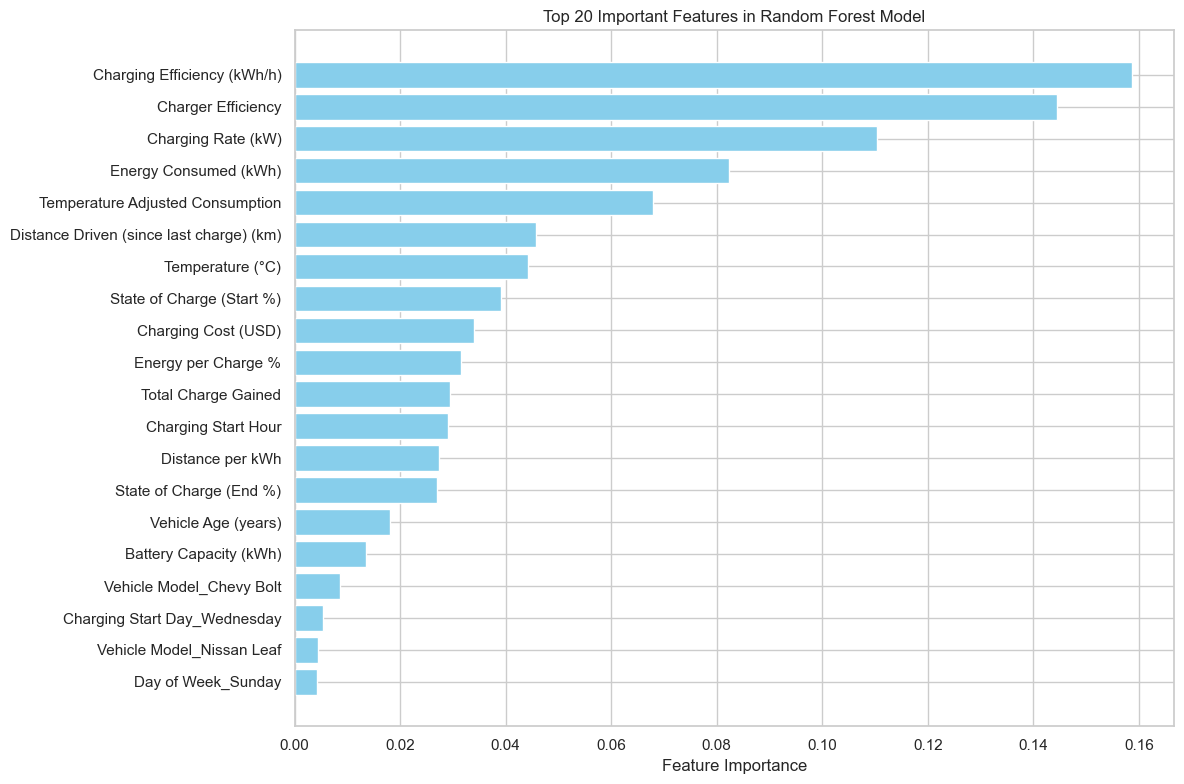

In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
# Import the specific RMSE function to avoid the TypeError
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Prepare Data
df_reg = ev_dataa.copy()

# 2. Categorical Encoding (Includes Day of Week to match your Colab graph)
cols_to_encode = ['Time of Day', 'Day of Week', 'Charging Start Day']
existing = [c for c in cols_to_encode if c in df_reg.columns]
if existing:
    df_reg = pd.get_dummies(df_reg, columns=existing, drop_first=True)

# 3. Define X and y
# Drop IDs and time-based leakages to keep the model "honest"
drop_list = ['Charging Duration (hours)', 'Charging Start Time', 'Charging End Time', 
             'User ID', 'Charging Station ID']
X = df_reg.drop(columns=[c for c in drop_list if c in df_reg.columns])

# Filter for numeric columns only
X = X.select_dtypes(include=[np.number, bool])
y = df_reg['Charging Duration (hours)']

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# 6. Make Predictions and Calculate Metrics
y_pred = rf_regressor.predict(X_test)

# FIX: Use the dedicated function instead of mean_squared_error(squared=False)
rmse_rf = root_mean_squared_error(y_test, y_pred)

print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# 7. Visualize Top Features (matching your Colab graph style)
importances = rf_regressor.feature_importances_
feat_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
# Showing top 20 ensures 'Day of Week' features appear at the bottom of the list
plt.barh(feat_importance['Feature'].head(20), feat_importance['Importance'].head(20), color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 20 Important Features in Random Forest Model')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

In [74]:
# --- SECTION: FINAL MODEL PREPARATION FOR STREAMLIT ---

# 1. CLEANING STEP: Remove rows where Energy is missing
# This prevents the "Input y contains NaN" error
clean_df = ev_data.dropna(subset=['Energy Consumed (kWh)'])

# 2. PREPARE FEATURES
target_reg = 'Energy Consumed (kWh)'

# Drop the target and all non-numeric/unnecessary columns
X_final = clean_df.drop(columns=[
    target_reg, 
    'Charging Start Time', 
    'Charging End Time', 
    'Charger Type',
    'User ID', 
    'Charging Station ID'
], errors='ignore')

# Convert categories to numbers
X_final = pd.get_dummies(X_final, drop_first=True)
y_final = clean_df[target_reg]

# 3. RE-TRAIN THE REGRESSOR
from sklearn.ensemble import RandomForestRegressor
reg_model_final = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model_final.fit(X_final, y_final) # Should run perfectly now!

# 4. EXPORT SECTION
import pickle
import os

if not os.path.exists('models'):
    os.makedirs('models')

# Save the Regressor
with open('models/energy_reg_model.pkl', 'wb') as f:
    pickle.dump(reg_model_final, f)

# Save the Feature Names (Matches the Streamlit inputs)
with open('models/feature_columns.pkl', 'wb') as f:
    pickle.dump(X_final.columns.tolist(), f)

# Save the Classifier (using your existing clf_model from earlier)
with open('models/charger_clf_model.pkl', 'wb') as f:
    pickle.dump(clf_model, f)

print(f"Success! Cleaned {len(clean_df)} rows and exported models.")

Success! Cleaned 1254 rows and exported models.


In [75]:

import pickle

print("Delay model updated successfully!")

print("All models and feature lists have been pickled successfully!")

import pickle
import os

# Create directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# Save the improved Delay Model
with open('models/delay_model.pkl', 'wb') as f:
    pickle.dump(classifier, f)

# CRITICAL: Save the list of features so the app knows the correct order
# This prevents the "Feature names seen at fit time, yet now missing" error
with open('models/model_features.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Models and features exported successfully!")

Delay model updated successfully!
All models and feature lists have been pickled successfully!
Models and features exported successfully!


In [76]:
# 1. DEFINE TARGET
target_reg = 'Energy Consumed (kWh)'

# 2. TOTAL CLEANING (Features + Target)
# Create a temporary copy to clean everything together first
reg_df = ev_data.copy()

# Drop rows where the target is missing
reg_df = reg_df.dropna(subset=[target_reg])

# Drop ID and non-numeric columns
X_reg = reg_df.drop(columns=[
    target_reg, 
    'Charging Start Time', 
    'Charging End Time', 
    'Charger Type',
    'User ID', 
    'Charging Station ID'
], errors='ignore')

# Convert remaining categories to dummies (0s and 1s)
X_reg = pd.get_dummies(X_reg, drop_first=True)

# Final check: Fill any tiny gaps in features with 0 or mean
X_reg = X_reg.fillna(0)

y_reg = reg_df[target_reg]

# 3. SPLIT
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 4. TRAIN REGRESSOR
from sklearn.ensemble import RandomForestRegressor
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train_reg, y_train_reg)

print(f" Success! Regressor trained on {len(X_train_reg)} rows.")

 Success! Regressor trained on 1003 rows.


In [77]:
# This line creates the missing variable!
y_pred_reg = reg_model.predict(X_test_reg)

# Now you can run the accuracy check
from sklearn.metrics import r2_score
print(f"Model Accuracy (R2 Score): {r2_score(y_test_reg, y_pred_reg):.2f}")

Model Accuracy (R2 Score): -0.03


In [78]:
import pickle
import os

# Create a folder to keep things organized
if not os.path.exists('models'):
    os.makedirs('models')

# 1. Save the Classifier (Charger Type Prediction)
with open('models/charger_clf_model.pkl', 'wb') as f:
    pickle.dump(clf_model, f)

# 2. Save the Label Encoder (Text-to-Number translation)
with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# 3. Save the Regressor (Energy Prediction)
with open('models/energy_reg_model.pkl', 'wb') as f:
    pickle.dump(reg_model, f)

# 4. Save the Feature Columns (Crucial for app consistency)
with open('models/feature_columns.pkl', 'wb') as f:
    pickle.dump(X_train_reg.columns.tolist(), f)

print("Success! All models saved")

Success! All models saved


In [80]:
# 1. Final Clean of the Data
# We use only rows where Energy exists for the Regressor, but this set works for both.
final_df = ev_data.dropna(subset=['Energy Consumed (kWh)'])

# 2. Define the exact columns both models will use
# We MUST drop 'Energy Consumed (kWh)' because that's what we want to predict!
features_to_drop = [
    'Energy Consumed (kWh)', 'Charging Start Time', 'Charging End Time', 
    'Charger Type', 'User ID', 'Charging Station ID'
]

X_final = final_df.drop(columns=features_to_drop, errors='ignore')
X_final = pd.get_dummies(X_final, drop_first=True)

# 3. Targets
y_reg = final_df['Energy Consumed (kWh)']
y_clf = final_df['Charger Type'] # For the classification model

# 4. Retrain BOTH Models with the same X_final
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Regressor
reg_model_final = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model_final.fit(X_final, y_reg)

# Classifier
le = LabelEncoder()
y_clf_encoded = le.fit_transform(y_clf)
clf_model_final = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model_final.fit(X_final, y_clf_encoded)

# 5. Export Everything (Overwrite old files)
import pickle
import os
if not os.path.exists('models'): os.makedirs('models')

with open('models/energy_reg_model.pkl', 'wb') as f:
    pickle.dump(reg_model_final, f)

with open('models/charger_clf_model.pkl', 'wb') as f:
    pickle.dump(clf_model_final, f)

with open('models/feature_columns.pkl', 'wb') as f:
    pickle.dump(X_final.columns.tolist(), f)

with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print(" DONE! Both models are now perfectly synced without 'Energy Consumed' in the features.")

 DONE! Both models are now perfectly synced without 'Energy Consumed' in the features.
